Title : Steam Games : Predicting Positive Review Ratings
Url : https://www.kaggle.com/code/shree0910/steam-games-predicting-positive-review-ratings

In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, RocCurveDisplay)
from scipy.sparse import hstack, csr_matrix
pd.set_option('display.max_columns', 50)
print('Libraries loaded successfully.')

Libraries loaded successfully.


 warings.filterwarnings('ignore')는 코드 자체는 실행되지만, 경고 메시지가 화면에 출력되지 않도록 숨기는 기능

In [5]:
df=pd.read_csv('C:\Git_for_study\DE\Practice\Kaggle\Data\Steam Games Dataset\extended_steam_games.csv')
print('Shape:', df.shape)
df.head(3)

Shape: (23100, 28)


,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,release_date,required_age,is_free,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,recommendations,achievements,genres,categories
0,730,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,1013936,"21 Aug, 2012",0.0,True,"For over two decades, Counter-Strike has offer...","Czech, Danish, Dutch, English<strong>*</strong...",True,False,True,NaN,5211693.0,1.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Stea..."
1,1172470,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,124262,"4 Nov, 2020",0.0,True,"Apex Legends is the award-winning, free-to-pla...","English<strong>*</strong>, French<strong>*</st...",True,False,False,88.0,1580.0,12.0,"Action, Adventure, Free To Play","Multi-player, PvP, Online PvP, Co-op, Online C..."
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,314682,"21 Dec, 2017",19.0,True,"PUBG: BATTLEGROUNDS, the high-stakes winner-ta...","English, Korean, Simplified Chinese, French, G...",True,False,False,NaN,1762488.0,37.0,"Action, Adventure, Massively Multiplayer, Free...","Multi-player, PvP, Online PvP, Custom Volume C..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23100 entries, 0 to 23099
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   appid                23100 non-null  int64  
 1   name                 23099 non-null  object 
 2   developer            23034 non-null  object 
 3   publisher            22967 non-null  object 
 4   positive             23100 non-null  int64  
 5   negative             23100 non-null  int64  
 6   owners               23100 non-null  object 
 7   average_forever      23100 non-null  int64  
 8   average_2weeks       23100 non-null  int64  
 9   median_forever       23100 non-null  int64  
 10  median_2weeks        23100 non-null  int64  
 11  price                23100 non-null  int64  
 12  initialprice         23100 non-null  int64  
 13  discount             23100 non-null  int64  
 14  ccu                  23100 non-null  int64  
 15  release_date         22998 non-null 

Games after filtering: 19582
label
1    0.729445
0    0.270555
Name: proportion, dtype: float64


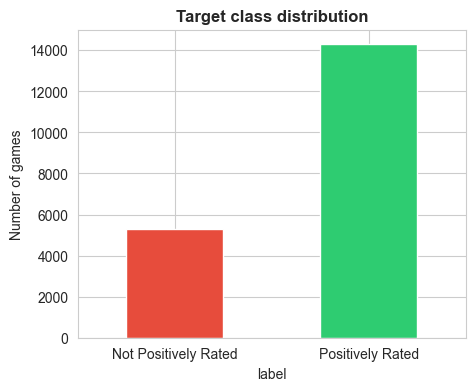

In [9]:
df['total_reviews']=df['positive']+df['negative']
df=df[df['total_reviews'] >=20].copy()
df['review_ratio']=df['positive']/df['total_reviews']
df['label']=(df['review_ratio'] >=0.70).astype(int)

print('Games after filtering:', df.shape[0])
print(df['label'].value_counts(normalize=True).rename('proportion'))

plt.figure(figsize=(5,4))
df['label'].value_counts().sort_index().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.xticks([0,1], ['Not Positively Rated', 'Positively Rated'], rotation=0)
plt.title('Target class distribution', fontweight='bold')
plt.ylabel('Number of games')
plt.show()

1. xticks로 x값의 범위를 정할 수 있는데, 리스트로 범위를 넘긴 다음에, 범위 대신 사용할 범주 문자열을 넘겨주면 그 걸로 표시되는 듯
2. 시각화 했을 때 레이블 비중에 차이가 있으므로, 향후 표본 추출과 학습 과정에서 불균형을 고려해야 함

In [11]:
df[['recommendations','positive']].corr()

KeyError: "None of [Index(['recommendations', 'positive'], dtype='object')] are in the [columns]"

In [10]:
print("Correlation of 'recommendations' with 'positive':",
      round(df[['recommendations','positive']].corr().iloc[0,1],3))

leak_cols=['positive','negative','recommendations','total_reviews','review_ratio']
df=df.drop(columns=leak_cols)
print('Dropped leakage columns:', leak_cols)

Correlation of 'recommendations' with 'positive': 0.96
Dropped leakage columns: ['positive', 'negative', 'recommendations', 'total_reviews', 'review_ratio']


In [17]:
def owners_midpoint(o):
    try:
        lo,hi=str(o).replace(',','').split('..')
        return (int(lo.strip())+int(hi.strip()))/2
    except Exception:
        return np.nan

df['owners_mid']=df['owners'].apply(owners_midpoint)
df['release_date']=pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']=df['release_date'].dt.year
df['num_languages']=df['supported_languages'].fillna('').apply(
    lambda x: len(x.split(',')) if x else 0)

df['desc_len']=df['short_description'].fillna('').apply(len)

df['num_genres']=df['genres'].fillna('').apply(
    lambda x: len([g for g in x.split(',') if g.strip()])
)

df['num_categories']=df['categories'].fillna('').apply(
    lambda x: len([g for g in x.split(',') if g.strip()])
)

df['genre_cat_text']=(df['genres'].fillna('')+' ' + df['categories'].fillna('')).str.replace(',', ' ')
df['has_metacritic']=df['metacritic_score'].notnull().astype(int)
df['metacretic_score']=df['metacritic_score'].fillna(df['metacritic_score'].median())

for c in ['is_free', 'platforms_windows','platforms_mac', 'platforms_linux']:
    df[c]=df[c].astype(str).map({'True':1, 'False':0}).fillna(0).astype(int)

df['achievements']=df['achievements'].fillna(0)
df['required_age']=df['required_age'].fillna(0)
df['owners_mid']=df['owners_mid'].fillna(df['owners_mid'].median())
df['release_year']=df['release_year'].fillna(df['release_year'].median())

print('Featrue engineering done, Shape now:', df.shape)
df[['owners_mid','release_year','num_languages','desc_len','num_genres','num_categories']].head()



Featrue engineering done, Shape now: (19582, 36)


,owners_mid,release_year,num_languages,desc_len,num_genres,num_categories
0,150000000.0,2012.0,29,224,2,19
1,150000000.0,2020.0,14,284,3,14
2,150000000.0,2017.0,17,248,4,11
3,75000000.0,2019.0,17,157,4,15
4,75000000.0,2007.0,27,169,2,19


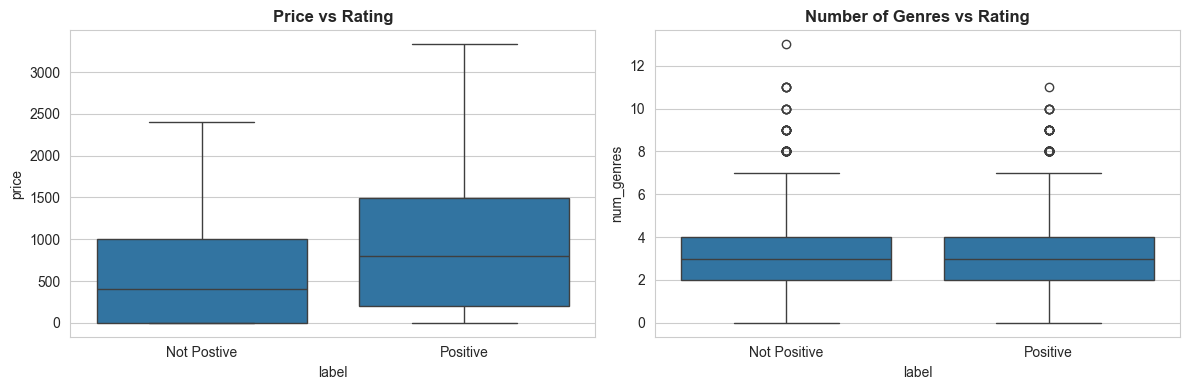

In [20]:
fig,axes=plt.subplots(1,2, figsize=(12,4))

sns.boxplot(data=df, x='label', y='price', ax=axes[0], showfliers=False)
axes[0].set_xticklabels(['Not Postive', 'Positive'])
axes[0].set_title('Price vs Rating', fontweight='bold')

sns.boxplot(data=df, x='label', y='num_genres', ax=axes[1])
axes[1].set_xticklabels(['Not Positive', 'Positive'])
axes[1].set_title('Number of Genres vs Rating', fontweight='bold')

plt.tight_layout()
plt.show()